In [ ]:
# We use uv for faster installation
!pip install uv
!uv pip install -q autogluon --system
!uv pip install -q autogluon.timeseries --system
!uv pip uninstall -q torchaudio torchvision torchtext --system # fix incompatible package versions on Colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 84.3 MB/s eta 0:00:00


## Zero-shot forecasting

We work with a subset of the [Australian Electricity Demand dataset](https://zenodo.org/records/4659727) and use Chronos-Bolt

In [ ]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [ ]:
data = TimeSeriesDataFrame.from_path(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/australian_electricity_subset/test.csv"
)
data.head()

target
item_id timestamp                       
T000000 2013-03-10 00:00:00  5207.959961
        2013-03-10 00:30:00  5002.275879
        2013-03-10 01:00:00  4747.569824
        2013-03-10 01:30:00  4544.880859
        2013-03-10 02:00:00  4425.952148

In [ ]:
prediction_length = 48
train_data, test_data = data.train_test_split(prediction_length)

Sorting the dataframe index before generating the train/test split.


We use the efficient Chronos-Bolt (Small, 48M) model in zero-shot mode, which as `6x` the number of parameters. We select the `"bolt_small"` presets to use the [Chronos-Bolt](https://huggingface.co/autogluon/chronos-bolt-small) (Small, 48M).

In [ ]:
predictor = TimeSeriesPredictor(prediction_length=prediction_length).fit(
    train_data, presets="bolt_small",
)

Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/ag-20260107_144618'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Pytorch Version:    2.9.0+cu126
CUDA Version:       12.6
GPU Memory:         GPU 0: 14.74/14.74 GB
Total GPU Memory:   Free: 14.74 GB, Allocated: 0.00 GB, Total: 14.74 GB
GPU Count:          1
Memory Avail:       11.33 GB / 12.67 GB (89.4%)
Disk Space Avail:   73.36 GB / 112.64 GB (65.1%)
Setting presets to: bolt_small

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'model_path': 'bolt_small'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 48,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 '

We use the `predict` method to generate forecasts, and the `plot` method to visualize them and see the accuracy



Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_small]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

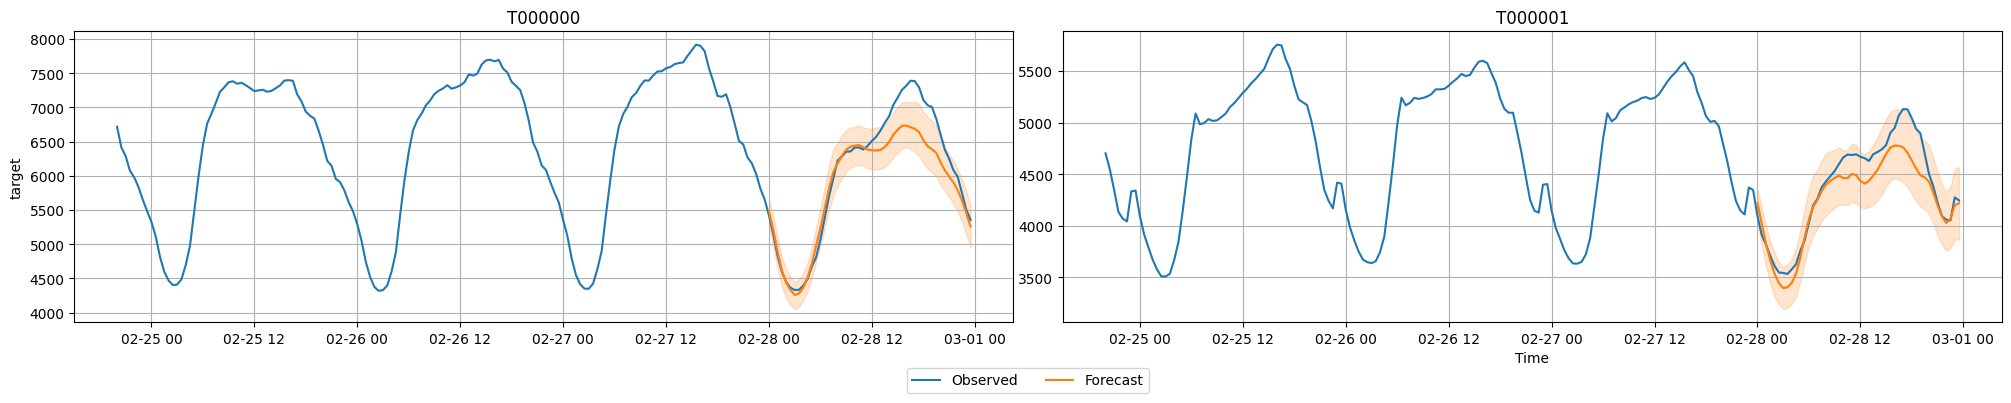

In [ ]:
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);